In [1]:
!pip install -q diffusers transformers accelerate

In [1]:
import torch
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.11.0+cu128
CUDA available: True


In [1]:
import torch
from diffusers import AutoPipelineForText2Image

print("Loading Stable Diffusion XL Turbo...")

pipe = AutoPipelineForText2Image.from_pretrained(
    "stabilityai/sdxl-turbo",
    torch_dtype=torch.float16,
    variant="fp16"
)

pipe = pipe.to("cuda")

print("Model loaded successfully!")

[transformers] `Siglip2ImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Siglip2ImageProcessor` instead.
/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Loading Stable Diffusion XL Turbo...


/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Model loaded successfully!


In [2]:
prompt = """
A futuristic smart city powered by renewable energy,
solar panels on buildings, clean electric transportation,
green parks, modern architecture, cinematic lighting,
highly detailed digital art
"""

print("Generating image...")

image = pipe(
    prompt=prompt,
    guidance_scale=0.0,
    num_inference_steps=4
).images[0]

image.save("generated_image.png")

print("Image generated successfully!")
print("Saved as generated_image.png")

Generating image...


  0%|          | 0/4 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


Image generated successfully!
Saved as generated_image.png


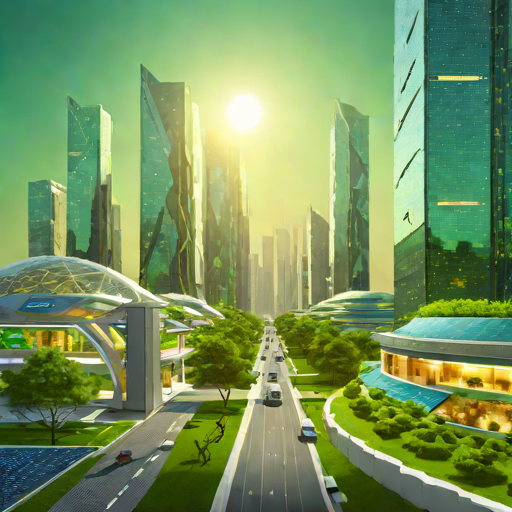

In [3]:
from IPython.display import display

display(image)

In [4]:
from google.colab import files

files.download("generated_image.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>